In [1]:
"""
Medical Insurance Cost Prediction Project
Dataset: Kaggle - Medical Cost Personal Datasets

Phase 1: Linear Regression + Polynomial
Phase 2: Multi-layer MLP Neural Network
Phase 3: ANFIS (Adaptive Neuro-Fuzzy Inference System) - Manual Implementation
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

In [2]:
# ══════════════════════════════════════════════════════
# 1. Data Loading and Exploration
# ══════════════════════════════════════════════════════
print("=" * 62)
print("  Medical Insurance Cost Prediction")
print("=" * 62)

df = pd.read_csv('insurance.csv')

print(f"\n[Data] Samples: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(df.head(3).to_string())
print("\n[Descriptive Statistics]")
print(df.describe().round(2).to_string())
print(f"\n[Missing Values] {df.isnull().sum().to_dict()}")

  Medical Insurance Cost Prediction

[Data] Samples: 1338  |  Columns: 7
   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620

[Descriptive Statistics]
           age      bmi  children   charges
count  1338.00  1338.00   1338.00   1338.00
mean     39.21    30.66      1.09  13270.42
std      14.05     6.10      1.21  12110.01
min      18.00    15.96      0.00   1121.87
25%      27.00    26.30      0.00   4740.29
50%      39.00    30.40      1.00   9382.03
75%      51.00    34.69      2.00  16639.91
max      64.00    53.13      5.00  63770.43

[Missing Values] {'age': 0, 'sex': 0, 'bmi': 0, 'children': 0, 'smoker': 0, 'region': 0, 'charges': 0}


In [3]:
# ══════════════════════════════════════════════════════
# 2. Preprocessing
# ══════════════════════════════════════════════════════
df_enc = df.copy()
le = LabelEncoder()
df_enc['sex']    = le.fit_transform(df['sex'])
df_enc['smoker'] = le.fit_transform(df['smoker'])
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)

feature_cols = [c for c in df_enc.columns if c != 'charges']
X = df_enc[feature_cols].values.astype(float)
y = df_enc['charges'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n[Preprocessing] Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Features: {feature_cols}")


[Preprocessing] Train: 1070 | Test: 268
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [4]:
# ══════════════════════════════════════════════════════
# Evaluation Function
# ══════════════════════════════════════════════════════
results = []

def evaluate(name, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"  {name:<35} RMSE={rmse:>9.2f}  MAE={mae:>9.2f}  R²={r2:.4f}")
    results.append({'name': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                    'pred': y_pred.copy(), 'actual': y_true.copy()})
    return r2

In [5]:
# ══════════════════════════════════════════════════════
# Phase 1: Regression
# ══════════════════════════════════════════════════════
print("\n" + "─" * 62)
print("  Phase 1: Regression Models (Baseline)")
print("─" * 62)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
evaluate("Linear Regression", y_test, lr.predict(X_test_sc))

poly_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression())
])
poly_pipe.fit(X_train, y_train)
evaluate("Polynomial Regression (d=2)", y_test, poly_pipe.predict(X_test))


──────────────────────────────────────────────────────────────
  Phase 1: Regression Models (Baseline)
──────────────────────────────────────────────────────────────
  Linear Regression                   RMSE=  5796.28  MAE=  4181.19  R²=0.7836
  Polynomial Regression (d=2)         RMSE=  4551.13  MAE=  2729.50  R²=0.8666


0.8665830903164842

In [6]:
# ══════════════════════════════════════════════════════
# Phase 2: MLP Neural Network
# ══════════════════════════════════════════════════════
print("\n" + "─" * 62)
print("  Phase 2: MLP Neural Network")
print("─" * 62)

for hidden, tag in [((64, 32), "MLP (64-32)"),
                    ((128, 64, 32), "MLP (128-64-32)"),
                    ((256, 128, 64, 32), "MLP (256-128-64-32)")]:
    mlp = MLPRegressor(hidden_layer_sizes=hidden, activation='relu',
                       solver='adam', max_iter=1000, early_stopping=True,
                       validation_fraction=0.1, random_state=42)
    mlp.fit(X_train_sc, y_train)
    evaluate(tag, y_test, mlp.predict(X_test_sc))


──────────────────────────────────────────────────────────────
  Phase 2: MLP Neural Network
──────────────────────────────────────────────────────────────
  MLP (64-32)                         RMSE=  5658.85  MAE=  4074.58  R²=0.7937
  MLP (128-64-32)                     RMSE=  4668.70  MAE=  2882.57  R²=0.8596
  MLP (256-128-64-32)                 RMSE=  4499.16  MAE=  2545.79  R²=0.8696


In [8]:
# ══════════════════════════════════════════════════════
# Phase 3: ANFIS (Adaptive Neuro-Fuzzy Inference System)
# Manual Implementation - Takagi-Sugeno Type 1
# ══════════════════════════════════════════════════════
print("\n" + "─" * 62)
print("  Phase 3: ANFIS - Adaptive Neuro-Fuzzy Inference System")
print("─" * 62)


class ANFIS:
    """
    ANFIS with Gaussian Membership Functions and Takagi-Sugeno output.

    Classic 5-layer architecture:
      L1  - Fuzzification   : Calculate membership degree with Gaussian MF
      L2  - Rule Strength   : Multiply membership degrees of each rule (AND)
      L3  - Normalization   : Normalize rule strengths
      L4  - Consequent      : Linear output of each rule (p·x + q)
      L5  - Defuzzification : Weighted average of outputs

    Learning: Gradient Descent on antecedent parameters (c, σ)
              and LSQ on consequent parameters (p, q) — Hybrid Learning
    """

    def __init__(self, n_rules=4, n_features=None, lr=0.005,
                 n_epochs=80, batch_size=64, random_state=42):
        self.n_rules    = n_rules
        self.lr         = lr
        self.n_epochs   = n_epochs
        self.batch_size = batch_size
        self.rs         = random_state
        self.n_features = n_features
        self.loss_hist  = []

    # ── Gaussian Functions ──
    @staticmethod
    def _gauss(x, c, sigma):
        return np.exp(-0.5 * ((x - c) / (sigma + 1e-9)) ** 2)

    def _fuzzify(self, X):
        # X: (N, F)  →  mu: (N, n_rules, F)
        mu = np.zeros((X.shape[0], self.n_rules, self.n_features))
        for r in range(self.n_rules):
            for f in range(self.n_features):
                mu[:, r, f] = self._gauss(X[:, f],
                                          self.c[r, f], self.sigma[r, f])
        return mu

    def _fire_strength(self, mu):
        # AND  → product  (N, n_rules)
        return np.prod(mu, axis=2) + 1e-12

    def _forward(self, X):
        mu   = self._fuzzify(X)
        w    = self._fire_strength(mu)
        w_n  = w / w.sum(axis=1, keepdims=True)          # normalized (N, R)
        Xe   = np.hstack([X, np.ones((X.shape[0], 1))])  # [x | 1]
        # rule output:  f_r = X @ p_r + q_r
        f    = Xe @ self.P.T                              # (N, R)
        y    = (w_n * f).sum(axis=1)                     # (N,)
        return y, w, w_n, mu, f

    def fit(self, X, y):
        np.random.seed(self.rs)
        N, F = X.shape
        self.n_features = F

        # Initialize randomly from data
        idx = np.random.choice(N, self.n_rules, replace=False)
        self.c     = X[idx].copy()                       # (R, F)
        self.sigma = np.ones((self.n_rules, F)) * 0.5

        # Consequent parameters: (R, F+1)
        self.P = np.random.randn(self.n_rules, F + 1) * 0.01

        for epoch in range(self.n_epochs):
            perm  = np.random.permutation(N)
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, N, self.batch_size):
                idx_b = perm[start:start + self.batch_size]
                Xb, yb = X[idx_b], y[idx_b]
                Nb = len(Xb)

                y_pred, w, w_n, mu, f = self._forward(Xb)
                err = y_pred - yb                        # (Nb,)
                epoch_loss += np.mean(err ** 2)
                n_batches  += 1

                # ── LSQ for consequent parameters ──
                Xe = np.hstack([Xb, np.ones((Nb, 1))])  # (Nb, F+1)
                for r in range(self.n_rules):
                    W_r = w_n[:, r]                      # (Nb,)
                    A   = W_r[:, None] * Xe              # (Nb, F+1)
                    b_r = W_r * yb
                    sol, _, _, _ = np.linalg.lstsq(A, b_r, rcond=None)
                    self.P[r] = sol

                # ── Gradient for c and sigma ──
                y_pred, w, w_n, mu, f = self._forward(Xb)
                err = y_pred - yb

                w_sum = w.sum(axis=1, keepdims=True)
                # δL/δw_n_r = err * (f_r - y_pred)
                d_wn = err[:, None] * (f - y_pred[:, None])
                # δw_n_r/δw_r
                d_w  = (d_wn * w_sum - w * d_wn.sum(axis=1, keepdims=True)) \
                       / (w_sum ** 2 + 1e-12)

                for r in range(self.n_rules):
                    for ftr in range(F):
                        # δw_r/δmu_{r,ftr} = prod_{j≠ftr} mu_{r,j}
                        others = np.prod(
                            np.delete(mu[:, r, :], ftr, axis=1), axis=1)
                        d_mu = d_w[:, r] * others

                        # δmu/δc  and  δmu/δσ
                        diff = (Xb[:, ftr] - self.c[r, ftr])
                        sig  = self.sigma[r, ftr] + 1e-9
                        g    = mu[:, r, ftr]

                        dc    = d_mu * g * diff / sig ** 2
                        dsig  = d_mu * g * diff ** 2 / sig ** 3

                        self.c[r, ftr]     -= self.lr * dc.mean()
                        self.sigma[r, ftr] -= self.lr * dsig.mean()
                        self.sigma[r, ftr]  = max(self.sigma[r, ftr], 0.01)

            self.loss_hist.append(epoch_loss / n_batches)
            if (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1:3d}/{self.n_epochs} "
                      f"– MSE: {self.loss_hist[-1]:,.1f}")

        return self

    def predict(self, X):
        y, *_ = self._forward(X)
        return y

# Data preparation for ANFIS (only 3 main features → speed and interpretability)
# age, bmi, smoker – highest correlation with charges
df_orig = df.copy()
df_orig['smoker_n'] = (df_orig['smoker'] == 'yes').astype(float)
X_anf = df_orig[['age', 'bmi', 'smoker_n']].values.astype(float)
y_anf = df_orig['charges'].values.astype(float)

X_anf_tr, X_anf_te, y_anf_tr, y_anf_te = train_test_split(
    X_anf, y_anf, test_size=0.2, random_state=42)

sc_anf = StandardScaler()
X_anf_tr_sc = sc_anf.fit_transform(X_anf_tr)
X_anf_te_sc = sc_anf.transform(X_anf_te)

# Diffrent rules
print("  Training ANFIS with different number of rules (Hybrid Learning)...")

best_anfis_r2 = -float('inf')
best_anfis_model = None

# تست کردن ۲، ۴ و ۸ قانون
for rules in [2, 4, 8]:
    print(f"\n  >> Training ANFIS with {rules} rules:")
    
    current_anfis = ANFIS(n_rules=rules, lr=0.005, n_epochs=80, batch_size=64, random_state=42)
    current_anfis.fit(X_anf_tr_sc, y_anf_tr)
    
    pred_anfis = current_anfis.predict(X_anf_te_sc)
    
    # اسم مدل را داینامیک می‌دهیم تا در نمودارها مشخص شود چند قانون داشته
    tag = f"ANFIS ({rules} rules)"
    r2 = evaluate(tag, y_anf_te, pred_anfis)
    
    # ذخیره بهترین مدل برای رسم نمودارهای آخر کد (توابع عضویت و Loss)
    if r2 > best_anfis_r2:
        best_anfis_r2 = r2
        best_anfis_model = current_anfis

# مدل نهایی را برابر بهترین مدل قرار می‌دهیم تا بقیه کدهای رسم نمودار ارور ندهند
anfis = best_anfis_model
print(f"\n  [!] Best ANFIS model selected: {anfis.n_rules} rules with R² = {best_anfis_r2:.4f}")
# -------------------------------------------------------------------------


──────────────────────────────────────────────────────────────
  Phase 3: ANFIS - Adaptive Neuro-Fuzzy Inference System
──────────────────────────────────────────────────────────────
  Training ANFIS with different number of rules (Hybrid Learning)...

  >> Training ANFIS with 2 rules:
    Epoch  20/80 – MSE: 40,486,293.5
    Epoch  40/80 – MSE: 41,663,227.8
    Epoch  60/80 – MSE: 39,584,463.0
    Epoch  80/80 – MSE: 39,802,423.8
  ANFIS (2 rules)                     RMSE=  6195.01  MAE=  4676.74  R²=0.7528

  >> Training ANFIS with 4 rules:
    Epoch  20/80 – MSE: 40,486,293.5
    Epoch  40/80 – MSE: 41,663,227.8
    Epoch  60/80 – MSE: 39,584,463.0
    Epoch  80/80 – MSE: 39,802,423.8
  ANFIS (4 rules)                     RMSE=  6195.01  MAE=  4676.74  R²=0.7528

  >> Training ANFIS with 8 rules:
    Epoch  20/80 – MSE: 42,652,499.6
    Epoch  40/80 – MSE: 41,662,685.2
    Epoch  60/80 – MSE: 39,583,997.0
    Epoch  80/80 – MSE: 39,801,942.3
  ANFIS (8 rules)                     RM

In [9]:
# ══════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("  Final Comparison")
print("=" * 62)
df_res = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ('pred', 'actual')}
                       for r in results])
df_res = df_res.sort_values('R2', ascending=False)
print(df_res.to_string(index=False))
print(f"\n  Best Model: {df_res.iloc[0]['name']}  "
      f"(R²={df_res.iloc[0]['R2']:.4f})")


  Final Comparison
                       name        RMSE         MAE       R2
        MLP (256-128-64-32) 4499.155117 2545.787427 0.869613
Polynomial Regression (d=2) 4551.132385 2729.500134 0.866583
            MLP (128-64-32) 4668.696486 2882.570010 0.859601
                MLP (64-32) 5658.850926 4074.584253 0.793734
          Linear Regression 5796.284659 4181.194474 0.783593
            ANFIS (8 rules) 6194.964474 4676.706904 0.752799
            ANFIS (2 rules) 6195.005171 4676.735622 0.752796
            ANFIS (4 rules) 6195.005171 4676.735622 0.752796

  Best Model: MLP (256-128-64-32)  (R²=0.8696)


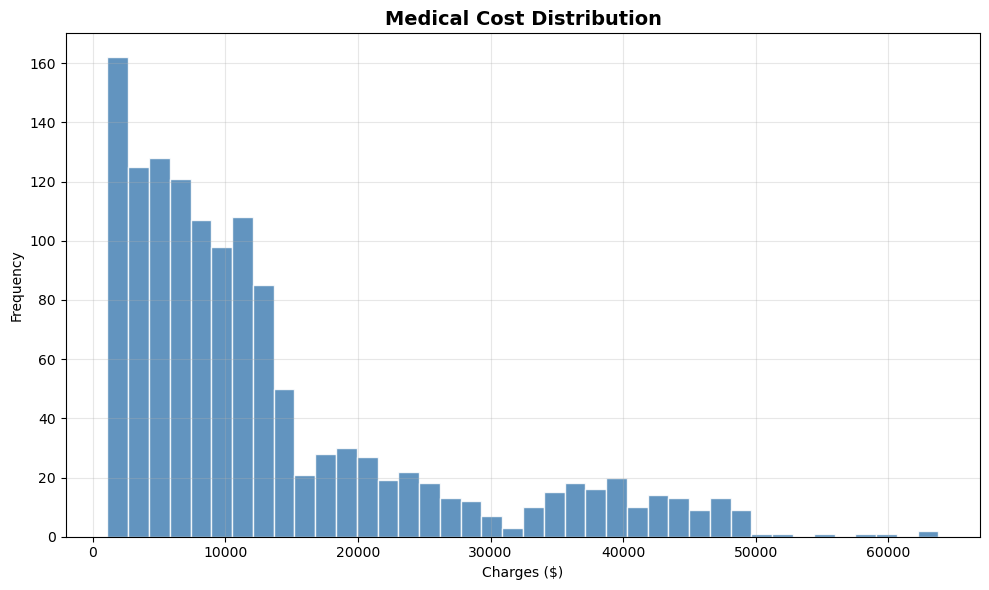

In [10]:
# ══════════════════════════════════════════════════════
# Visualization - All Figures Displayed Simultaneously
# ══════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────
# Figure 1: Medical Cost Distribution
# ──────────────────────────────────────────────────────────
plt.figure(1, figsize=(10, 6))
plt.hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Medical Cost Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()

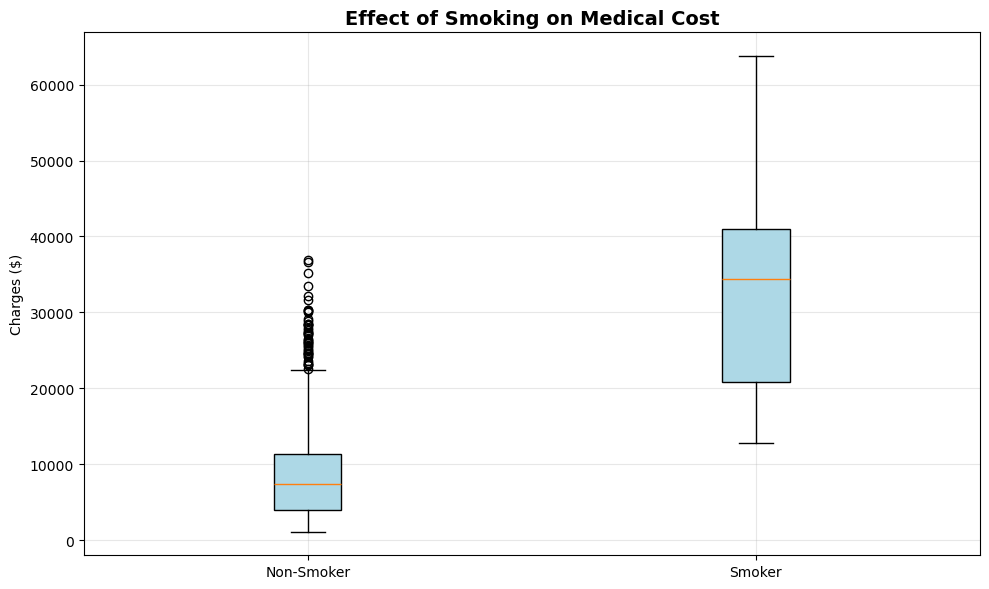

In [11]:
# ──────────────────────────────────────────────────────────
# Figure 2: Effect of Smoking on Cost
# ──────────────────────────────────────────────────────────
plt.figure(2, figsize=(10, 6))
plt.boxplot([df[df.smoker=='no']['charges'], df[df.smoker=='yes']['charges']],
            labels=['Non-Smoker', 'Smoker'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Effect of Smoking on Medical Cost', fontsize=14, fontweight='bold')
plt.ylabel('Charges ($)')
plt.grid(alpha=0.3)
plt.tight_layout()

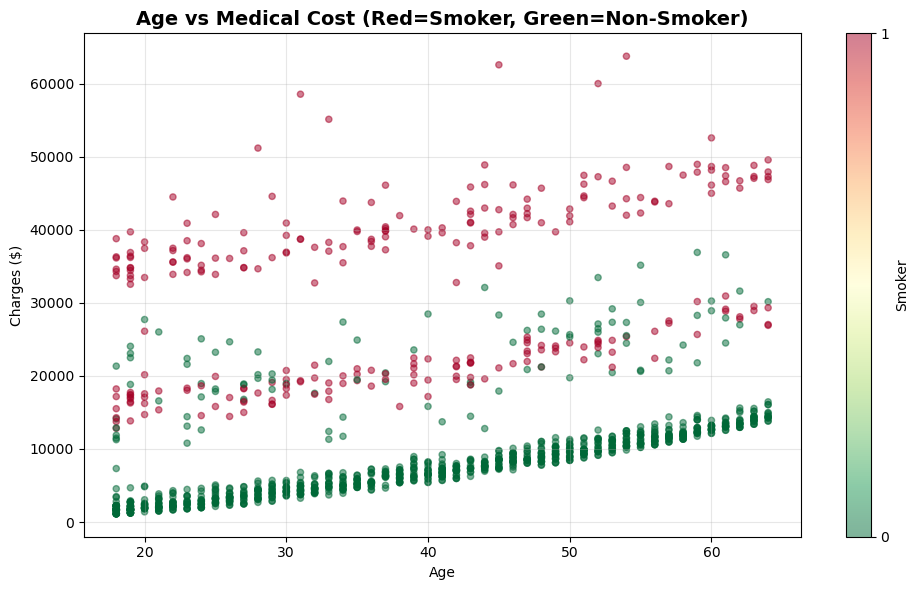

In [12]:
# ──────────────────────────────────────────────────────────
# Figure 3: Age vs Cost (Colored by Smoking Status)
# ──────────────────────────────────────────────────────────
plt.figure(3, figsize=(10, 6))
c_color = (df['smoker'] == 'yes').astype(int)
scatter = plt.scatter(df['age'], df['charges'], c=c_color, 
                     cmap='RdYlGn_r', alpha=0.5, s=20)
plt.title('Age vs Medical Cost (Red=Smoker, Green=Non-Smoker)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.colorbar(scatter, ticks=[0, 1], label='Smoker')
plt.grid(alpha=0.3)
plt.tight_layout()

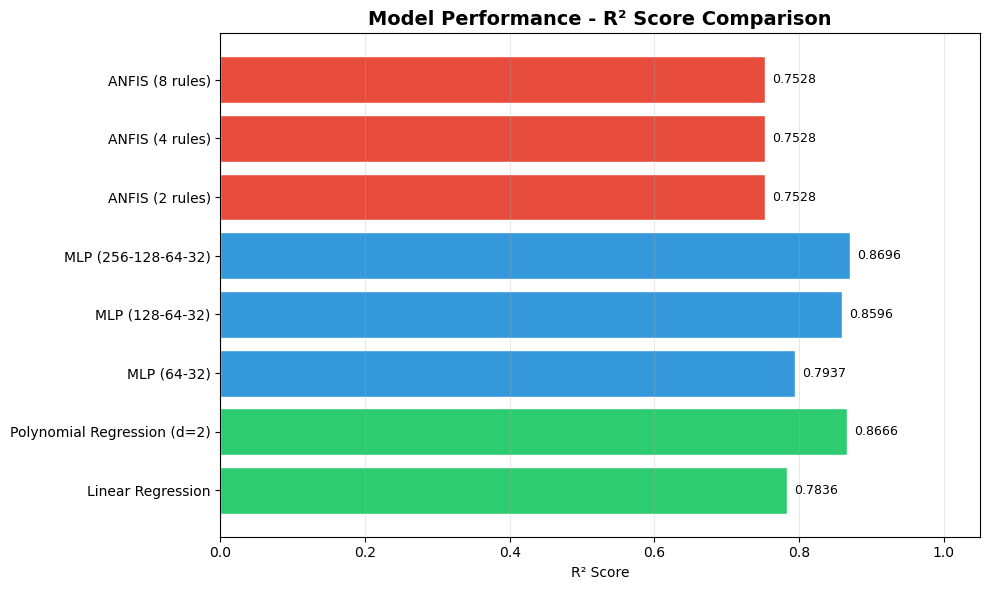

In [13]:
# ──────────────────────────────────────────────────────────
# Figure 4: Model Performance - R² Score Comparison
# ──────────────────────────────────────────────────────────
plt.figure(4, figsize=(10, 6))
names = [r['name'] for r in results]
r2s = [r['R2'] for r in results]
colors = ['#e74c3c' if 'ANFIS' in n else '#3498db' if 'MLP' in n else '#2ecc71'
          for n in names]

bars = plt.barh(names, r2s, color=colors, edgecolor='white')
plt.xlim(0, 1.05)
plt.title('Model Performance - R² Score Comparison', fontsize=14, fontweight='bold')
plt.xlabel('R² Score')
for bar, val in zip(bars, r2s):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()

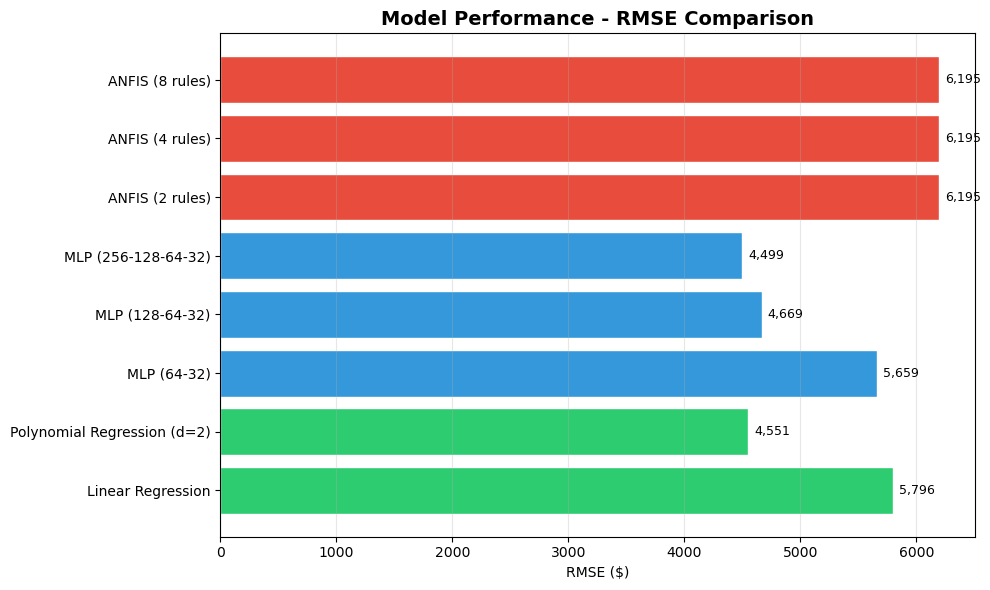

In [14]:
# ──────────────────────────────────────────────────────────
# Figure 5: Model Performance - RMSE Comparison
# ──────────────────────────────────────────────────────────
plt.figure(5, figsize=(10, 6))
rmses = [r['RMSE'] for r in results]
bars2 = plt.barh(names, rmses, color=colors, edgecolor='white')
plt.title('Model Performance - RMSE Comparison', fontsize=14, fontweight='bold')
plt.xlabel('RMSE ($)')
for bar, val in zip(bars2, rmses):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()

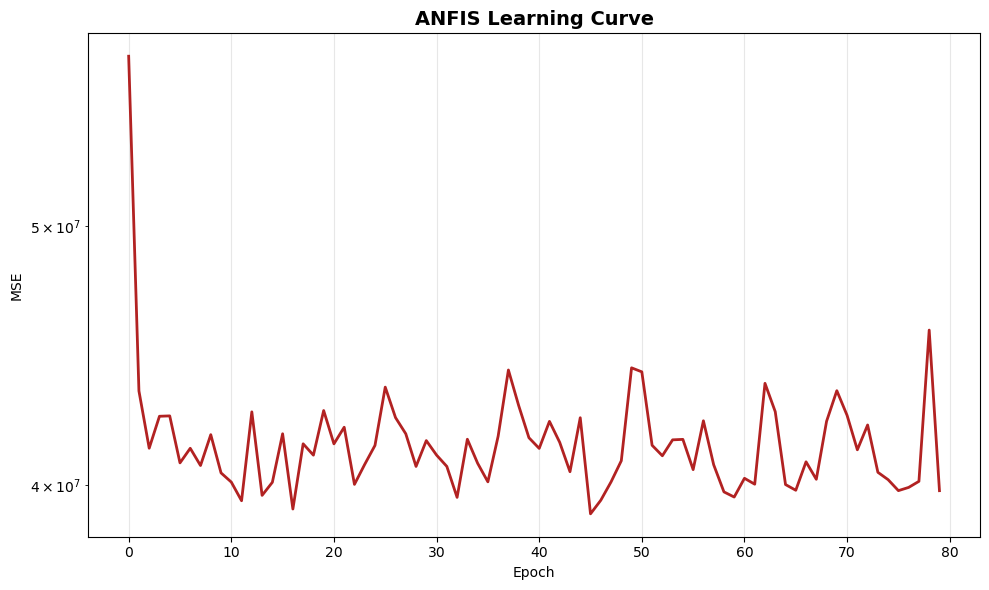

In [15]:
# ──────────────────────────────────────────────────────────
# Figure 6: ANFIS Learning Curve
# ──────────────────────────────────────────────────────────
plt.figure(6, figsize=(10, 6))
plt.plot(anfis.loss_hist, color='firebrick', lw=2)
plt.title('ANFIS Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()

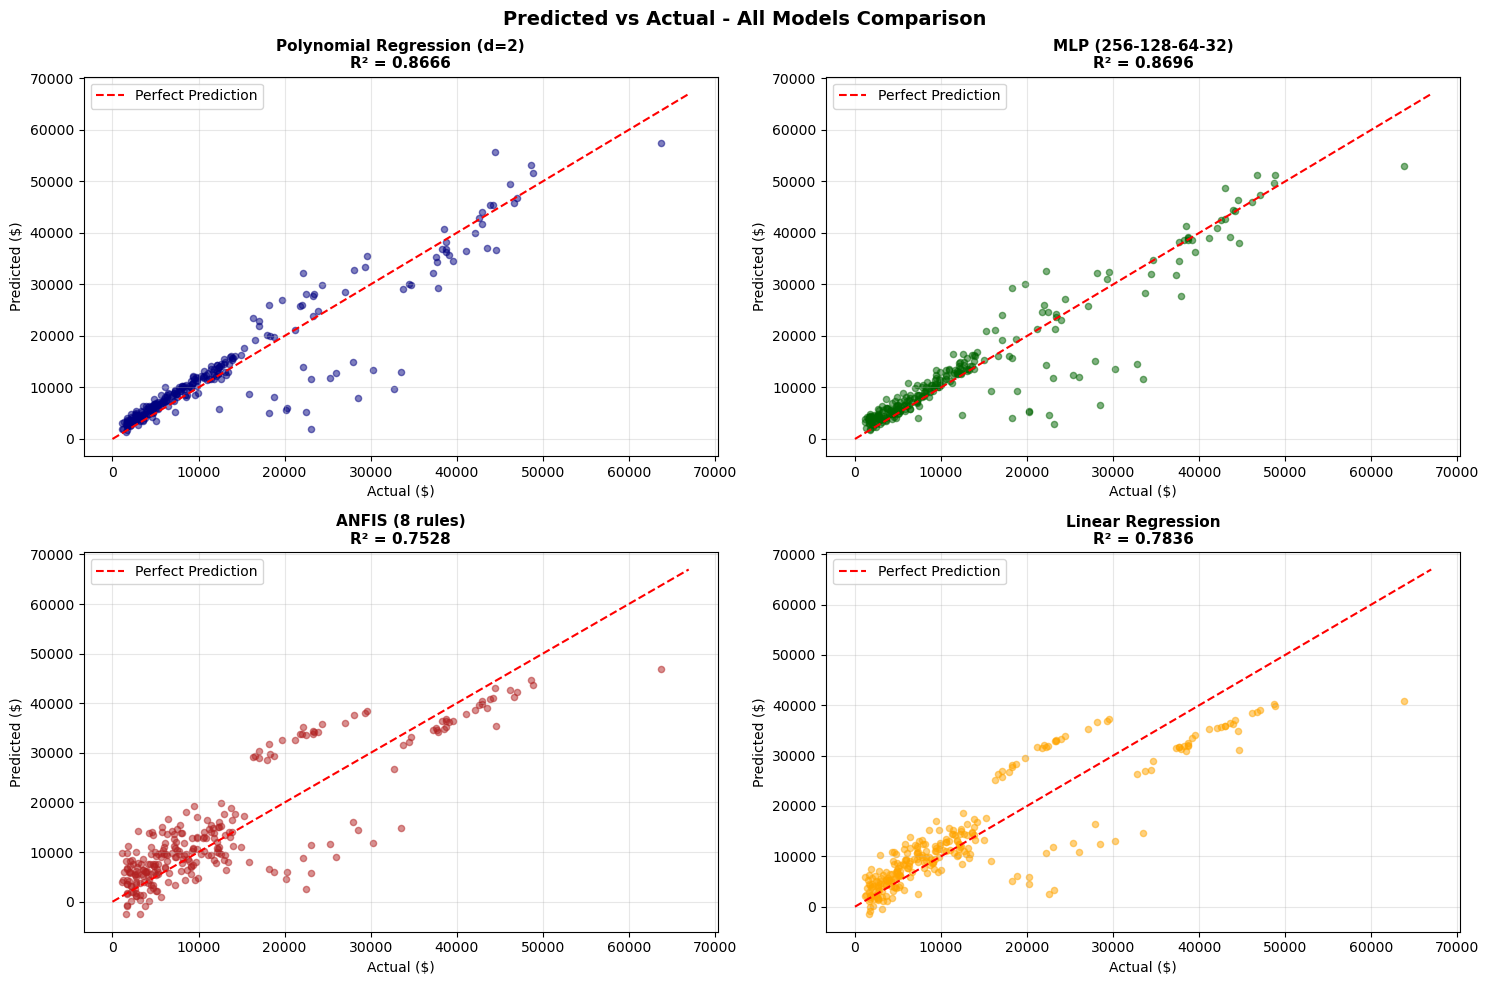

In [16]:
# ──────────────────────────────────────────────────────────
# Figure 7: Predicted vs Actual - Best Models Comparison
# ──────────────────────────────────────────────────────────
plt.figure(7, figsize=(15, 10))

# Subplot 1: Polynomial
poly_r = next(r for r in results if 'Poly' in r['name'])
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(poly_r['actual'], poly_r['pred'], alpha=0.5, s=20, color='navy')
lim = max(poly_r['actual'].max(), poly_r['pred'].max()) * 1.05
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect Prediction')
ax1.set_title(f'Polynomial Regression (d=2)\nR² = {poly_r["R2"]:.4f}', 
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Actual ($)')
ax1.set_ylabel('Predicted ($)')
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Best MLP
best_mlp = max([r for r in results if 'MLP' in r['name']], key=lambda x: x['R2'])
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(best_mlp['actual'], best_mlp['pred'], alpha=0.5, s=20, color='darkgreen')
lim = max(best_mlp['actual'].max(), best_mlp['pred'].max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect Prediction')
ax2.set_title(f'{best_mlp["name"]}\nR² = {best_mlp["R2"]:.4f}', 
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Actual ($)')
ax2.set_ylabel('Predicted ($)')
ax2.legend()
ax2.grid(alpha=0.3)

# Subplot 3: Best ANFIS
best_anfis_r = max([r for r in results if 'ANFIS' in r['name']], key=lambda x: x['R2'])
ax3 = plt.subplot(2, 2, 3)
ax3.scatter(best_anfis_r['actual'], best_anfis_r['pred'], alpha=0.5, s=20, color='firebrick')
lim = max(best_anfis_r['actual'].max(), best_anfis_r['pred'].max()) * 1.05
ax3.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect Prediction')
ax3.set_title(f'{best_anfis_r["name"]}\nR² = {best_anfis_r["R2"]:.4f}', 
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Actual ($)')
ax3.set_ylabel('Predicted ($)')
ax3.legend()
ax3.grid(alpha=0.3)

# Subplot 4: Linear Regression
lr_r = next(r for r in results if 'Linear' in r['name'])
ax4 = plt.subplot(2, 2, 4)
ax4.scatter(lr_r['actual'], lr_r['pred'], alpha=0.5, s=20, color='orange')
lim = max(lr_r['actual'].max(), lr_r['pred'].max()) * 1.05
ax4.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect Prediction')
ax4.set_title(f'Linear Regression\nR² = {lr_r["R2"]:.4f}', 
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Actual ($)')
ax4.set_ylabel('Predicted ($)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle('Predicted vs Actual - All Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()

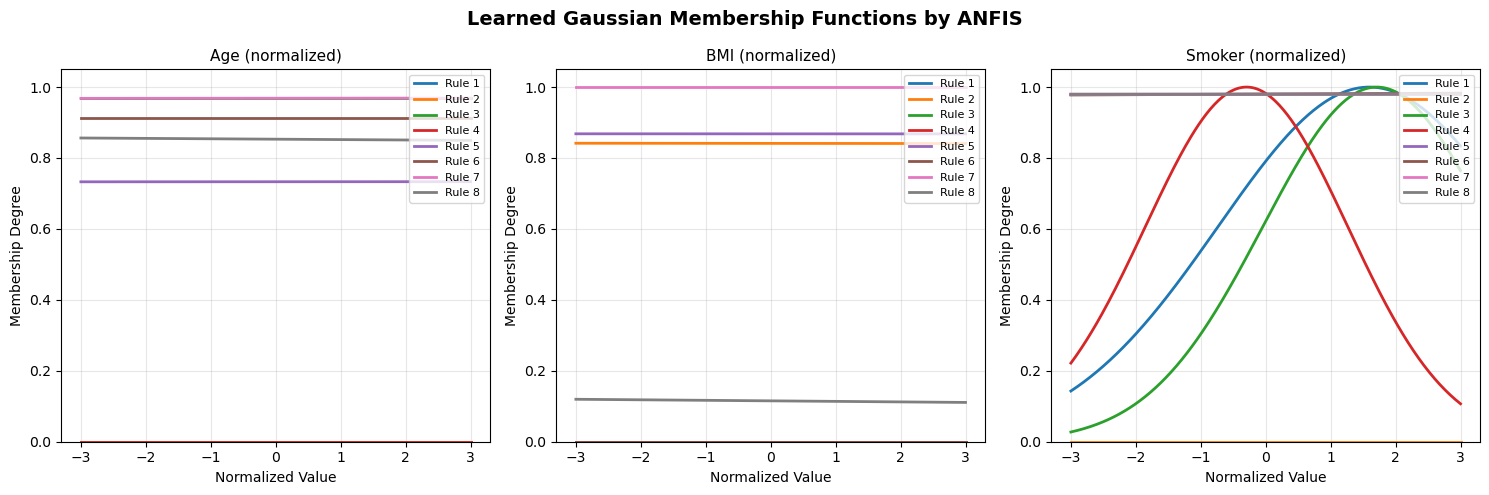

In [17]:
# ──────────────────────────────────────────────────────────
# Figure 8: ANFIS Membership Functions
# ──────────────────────────────────────────────────────────
plt.figure(8, figsize=(15, 5))
plt.suptitle('Learned Gaussian Membership Functions by ANFIS', 
              fontsize=14, fontweight='bold')

feat_names = ['Age (normalized)', 'BMI (normalized)', 'Smoker (normalized)']
x_range = np.linspace(-3, 3, 300)
cmap = plt.cm.tab10

for fi in range(3):
    ax = plt.subplot(1, 3, fi+1)
    for r in range(anfis.n_rules):
        c_r = anfis.c[r, fi]
        sig_r = anfis.sigma[r, fi]
        mu_vals = np.exp(-0.5 * ((x_range - c_r) / (sig_r + 1e-9)) ** 2)
        ax.plot(x_range, mu_vals, color=cmap(r), lw=2, label=f'Rule {r+1}')
    ax.set_title(feat_names[fi], fontsize=11)
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Membership Degree')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()

In [18]:
# ──────────────────────────────────────────────────────────
# Show all figures together
# ──────────────────────────────────────────────────────────
plt.show()

print("\n[✓] Project completed successfully.")
print("[✓] All 8 figures displayed in separate windows simultaneously.")


[✓] Project completed successfully.
[✓] All 8 figures displayed in separate windows simultaneously.
